## Modeling for predicting critical outcome at ED triage

Work Flow:
1. Task-specific filter
2. Variable selection
3. Modeling script
4. Performance output


### Load train and test

In [1]:
##USE PYTHON3.10-Rich1.0 KERNEL
import os
import time
import random
import tensorflow as tf
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import optimizers, metrics
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import load_model
from helpers import PlotROCCurve
from dataset_path import output_path

df_train = pd.read_csv('mv_train.csv')
df_test = pd.read_csv('mv_test.csv')
df_val = pd.read_csv("mv_val.csv")
confidence_interval = 95
random_seed = 0

2026-03-15 22:56:36.937559: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 22:56:36.972142: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-15 22:56:36.972178: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-15 22:56:36.973757: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-15 22:56:36.980700: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 22:56:36.981612: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
random.seed(random_seed)
np.random.seed(random_seed)

In [3]:
pd.set_option('display.max_columns', 100) 
pd.set_option('display.max_rows', 100) 

df_train.head()

,index,subject_id,hadm_id,stay_id,intime,outtime,anchor_age,gender,anchor_year,dod,admittime,dischtime,deathtime,ethnicity,edregtime,edouttime,insurance,in_year,age,outcome_inhospital_mortality,ed_death,before_ed_mortality,ed_los,intime_icu,time_to_icu_transfer,outcome_icu_transfer_12h,outcome_hospitalization,outcome_critical,n_ed_30d,n_ed_90d,n_ed_365d,next_ed_visit_time,next_ed_visit_time_diff,outcome_ed_revisit_3d,n_hosp_30d,n_hosp_90d,n_hosp_365d,n_icu_30d,n_icu_90d,n_icu_365d,ed_los_hours,time_to_icu_transfer_hours,next_ed_visit_time_diff_days,triage_temperature,triage_heartrate,triage_resprate,triage_o2sat,triage_sbp,triage_dbp,triage_pain,...,eci_CHF,eci_Arrhythmia,eci_Valvular,eci_PHTN,eci_PVD,eci_HTN1,eci_HTN2,eci_Paralysis,eci_NeuroOther,eci_Pulmonary,eci_DM1,eci_DM2,eci_Hypothyroid,eci_Renal,eci_Liver,eci_PUD,eci_HIV,eci_Lymphoma,eci_Tumor2,eci_Tumor1,eci_Rheumatic,eci_Coagulopathy,eci_Obesity,eci_WeightLoss,eci_FluidsLytes,eci_BloodLoss,eci_Anemia,eci_Alcohol,eci_Drugs,eci_Psychoses,eci_Depression,ed_temperature_last,ed_heartrate_last,ed_resprate_last,ed_o2sat_last,ed_sbp_last,ed_dbp_last,ed_pain_last,n_med,n_medrecon,triage_MAP,score_CCI,score_CART,score_REMS,score_NEWS,score_NEWS2,score_MEWS,split,notes,ecg_paths
0,69219,12174269,NaN,32252456,2115-03-05 18:52:00,2115-03-05 18:54:00,30,F,2115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2115,30,False,False,False,0 days 00:02:00,NaN,NaN,False,False,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,0.03,NaN,NaN,36.722222,70.0,20.0,100.0,142.0,71.0,5.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.833333,73.0,16.0,98.0,117.0,79.0,5.0,0.0,1.0,94.666667,0,0,0,0,0,1,train,examination ankle ap mortise and lat left indi...,['files/p1217/p12174269/s47575777/47575777']
1,374706,16975219,NaN,36792323,2123-11-26 04:52:00,2123-11-26 06:13:00,47,M,2121,NaN,NaN,NaN,NaN,HISPANIC/LATINO,NaN,NaN,NaN,2123,49,False,False,False,0 days 01:21:00,NaN,NaN,False,False,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,1.35,NaN,NaN,37.388889,112.0,18.0,95.0,140.0,97.0,10.000000,...,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,36.611111,85.0,18.0,97.0,113.0,73.0,7.0,5.0,0.0,111.333333,1,4,6,3,2,3,train,indication year old man with right shoulder pa...,['files/p1697/p16975219/s49058539/49058539']
2,392693,10199379,NaN,38089639,2161-04-10 13:43:00,2161-04-10 13:49:00,30,F,2157,NaN,NaN,NaN,NaN,WHITE,NaN,NaN,NaN,2161,34,False,False,False,0 days 00:06:00,NaN,NaN,False,False,False,0,0,2,NaN,NaN,False,0,0,2,0,0,0,0.10,NaN,NaN,36.222222,80.0,20.0,100.0,133.0,93.0,0.000000,...,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,37.055556,77.0,16.0,100.0,107.0,75.0,0.0,0.0,2.0,106.333333,1,0,0,0,0,1,test,i ve been getting more i scheduled an appointm...,['files/p1019/p10199379/s41948308/41948308']
3,386691,19101434,25207489.0,33105183,2191-05-10 20:19:00,2191-05-10 22:27:54,64,M,2188,NaN,2191-05-10 22:26:00,2191-05-11 14:53:00,NaN,WHITE,2191-05-10 20:19:00,2191-05-11 00:24:00,Other,2191,67,False,False,False,0 days 02:08:54,NaN,NaN,False,True,False,1,3,3,2191-10-13 11:10:00,155 days 12:42:06,False,1,2,2,0,0,0,2.15,NaN,155.53,36.712811,86.0,16.0,94.0,151.0,88.0,4.167576,...,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,36.666667,78.0,18.0,97.0,157.0,92.0,4.0,5.0,6.0,109.000000,3,4,5,1,0,1,train,malaise hypotension baradycardia anemia mr is ...,['files/p1910/p19101434/s44754723/44754723']
4,20499,13593727,25433469.0,34482189,2113-05-24 15:20:00,2113-05-24 20:50:19,52,M,2112,NaN,2113-05-24 20:49:00,2113-05-30 20:01:00,NaN,BLACK/AFRICAN AMERICAN,2113-05-24 15:20:00,2113-05-25 04:34:00,Other,2113,53,False,False,False,0 days 05:30:19,NaN,NaN,False,True,False,0,0,0,2113-05-31 13:34:00,6 days 16:43:41,False,0,0,2,0,0,0,5.51,NaN,6.70,36.833333,79.0,18.0,99.0,115.0,62.0,7.000000,...,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.722222,78.0,18.0,98.0,128.0,68.0,8.0,5.0,13.0,79.666667,4,0,2,0,0,1,train,esrd mr is a year old male with hep c w fibros...,['files/p13

### 1. Task-specific filter: no task-specific exclusion needed

In [4]:
print('training size =', len(df_train), ', testing size =', len(df_test))

training size = 130094 , testing size = 16262


### 2. Variable Selection

In [5]:
variable = ["age", "gender", 
            
            "n_ed_30d", "n_ed_90d", "n_ed_365d", "n_hosp_30d", "n_hosp_90d", 
            "n_hosp_365d", "n_icu_30d", "n_icu_90d", "n_icu_365d", 
            
            "triage_temperature", "triage_heartrate", "triage_resprate", 
            "triage_o2sat", "triage_sbp", "triage_dbp", "triage_pain", "triage_acuity",
            
            "chiefcom_chest_pain", "chiefcom_abdominal_pain", "chiefcom_headache",
            "chiefcom_shortness_of_breath", "chiefcom_back_pain", "chiefcom_cough", 
            "chiefcom_nausea_vomiting", "chiefcom_fever_chills", "chiefcom_syncope", 
            "chiefcom_dizziness", 
            
            "cci_MI", "cci_CHF", "cci_PVD", "cci_Stroke", "cci_Dementia", 
            "cci_Pulmonary", "cci_Rheumatic", "cci_PUD", "cci_Liver1", "cci_DM1", 
            "cci_DM2", "cci_Paralysis", "cci_Renal", "cci_Cancer1", "cci_Liver2", 
            "cci_Cancer2", "cci_HIV", 
            
            "eci_Arrhythmia", "eci_Valvular", "eci_PHTN",  "eci_HTN1", "eci_HTN2", 
            "eci_NeuroOther", "eci_Hypothyroid", "eci_Lymphoma", "eci_Coagulopathy", 
            "eci_Obesity", "eci_WeightLoss", "eci_FluidsLytes", "eci_BloodLoss",
            "eci_Anemia", "eci_Alcohol", "eci_Drugs","eci_Psychoses", "eci_Depression"]

outcome = "outcome_critical"

In [6]:
X_train = df_train[variable].copy()
y_train = df_train[outcome].copy()
X_test = df_test[variable].copy()
y_test = df_test[outcome].copy()
X_val = df_val[variable].copy()
y_val = df_val[outcome].copy()

In [7]:
X_train.dtypes.to_frame().T

,age,gender,n_ed_30d,n_ed_90d,n_ed_365d,n_hosp_30d,n_hosp_90d,n_hosp_365d,n_icu_30d,n_icu_90d,n_icu_365d,triage_temperature,triage_heartrate,triage_resprate,triage_o2sat,triage_sbp,triage_dbp,triage_pain,triage_acuity,chiefcom_chest_pain,chiefcom_abdominal_pain,chiefcom_headache,chiefcom_shortness_of_breath,chiefcom_back_pain,chiefcom_cough,chiefcom_nausea_vomiting,chiefcom_fever_chills,chiefcom_syncope,chiefcom_dizziness,cci_MI,cci_CHF,cci_PVD,cci_Stroke,cci_Dementia,cci_Pulmonary,cci_Rheumatic,cci_PUD,cci_Liver1,cci_DM1,cci_DM2,cci_Paralysis,cci_Renal,cci_Cancer1,cci_Liver2,cci_Cancer2,cci_HIV,eci_Arrhythmia,eci_Valvular,eci_PHTN,eci_HTN1,eci_HTN2,eci_NeuroOther,eci_Hypothyroid,eci_Lymphoma,eci_Coagulopathy,eci_Obesity,eci_WeightLoss,eci_FluidsLytes,eci_BloodLoss,eci_Anemia,eci_Alcohol,eci_Drugs,eci_Psychoses,eci_Depression
0,int64,object,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64


In [8]:
encoder = LabelEncoder()
X_train['gender'] = encoder.fit_transform(X_train['gender'])
X_test['gender'] = encoder.transform(X_test['gender'])
X_val['gender'] = encoder.transform(X_val['gender'])

In [9]:
print('class ratio')
ratio = y_train.sum()/(~y_train).sum()
print('positive : negative =', ratio, ': 1')

class ratio
positive : negative = 0.08756970046564509 : 1


### 3.  Modeling script

In [10]:
# Containers for all results
result_list = []

Logistic Regression:


/opt/python-env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training time: 4.972957372665405 seconds
AUC: 0.8376058509905909
AUPRC: 0.3461673787943857
Sensitivity: 0.7866043613707165
Specificity: 0.7247296034183469
Score thresold: 0.072238124507708
2.5 97.5


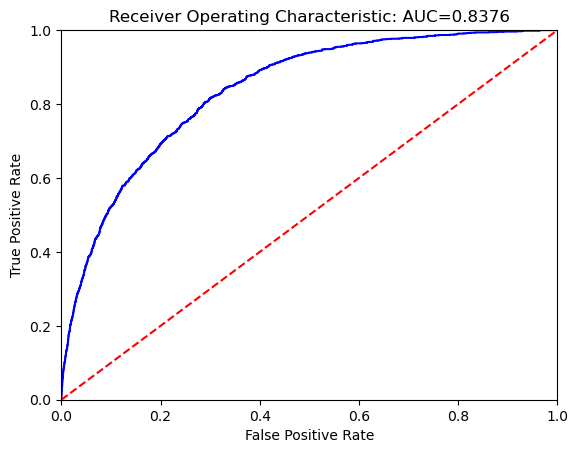

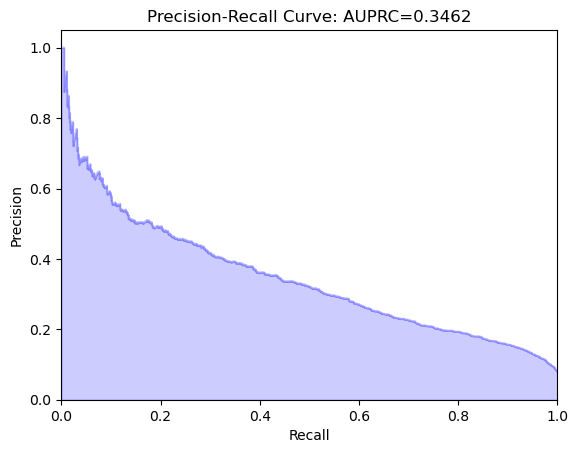

In [11]:
print("Logistic Regression:")
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(random_state=random_seed)
start = time.time()
logreg.fit(X_train,y_train)
runtime = time.time()-start
import pickle
with open('task2_logreg.pickle', 'wb') as model_dump:
    pickle.dump(logreg, model_dump)
print('Training time:', runtime, 'seconds')
probs = logreg.predict_proba(X_test)
result = PlotROCCurve(probs[:,1], y_test, ci=confidence_interval, random_seed=random_seed)

results = ["LR"]
results.extend(result)
results.append(runtime)
result_list.append(results)

RandomForest:
Training time: 19.85253143310547 seconds
AUC: 0.8591618173944838
AUPRC: 0.40665359355685926
Sensitivity: 0.764018691588785
Specificity: 0.7965015355855254
Score thresold: 0.10316666666666667
2.5 97.5


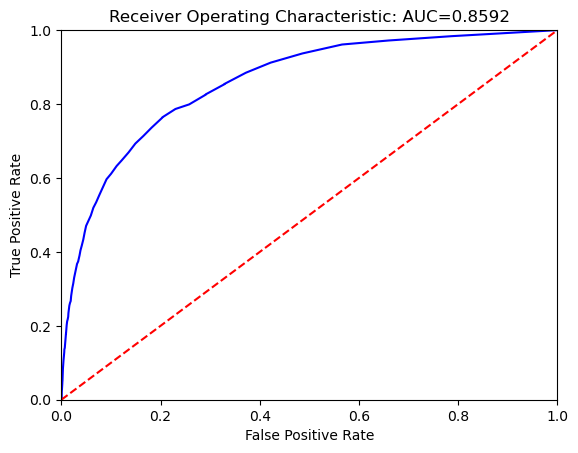

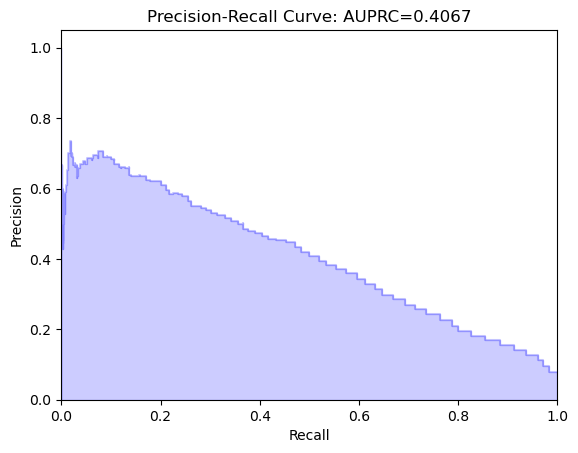

[0.07159149 0.01314451 0.00927881 0.01487869 0.02659205 0.00940825
 0.01510306 0.02524813 0.00519638 0.01091707 0.01962043 0.06100072
 0.08093231 0.05127823 0.04975677 0.08066805 0.0662904  0.03687067
 0.068893   0.00518804 0.00525729 0.00217492 0.00196877 0.0018192
 0.0026312  0.00304027 0.0046725  0.00242014 0.00253349 0.00869034
 0.00893244 0.00823683 0.00800941 0.00460158 0.01076093 0.00419989
 0.00437194 0.00710412 0.01107912 0.00767218 0.0034586  0.00768905
 0.00815127 0.00439765 0.00579302 0.00203837 0.01026907 0.00764094
 0.00741034 0.00755202 0.01216334 0.00870762 0.00865505 0.00304716
 0.0083832  0.00867503 0.00702495 0.00995824 0.00378205 0.00718
 0.00655618 0.00520808 0.0038235  0.01040165]


In [12]:
print("RandomForest:")
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(random_state=random_seed)
start = time.time()
rf.fit(X_train,y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
probs = rf.predict_proba(X_test)
result = PlotROCCurve(probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)
importances = rf.feature_importances_
print(importances)

results = ["RF"]
results.extend(result)
results.append(runtime)
result_list.append(results)

GradientBoosting:
Training time: 26.462765216827393 seconds
AUC: 0.8694154593923632
AUPRC: 0.42415663020755723
Sensitivity: 0.8115264797507789
Specificity: 0.7627186540259047
Score thresold: 0.07056303908116777
2.5 97.5


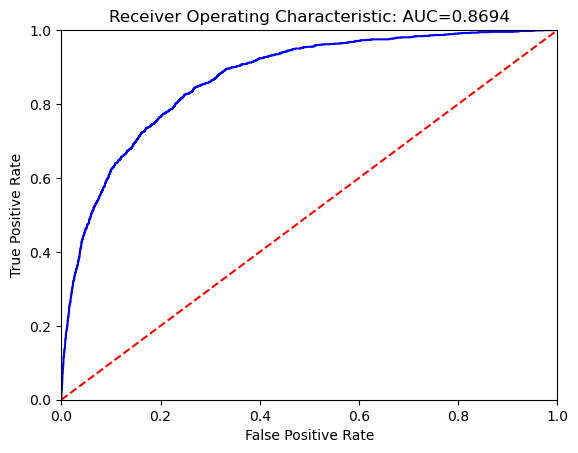

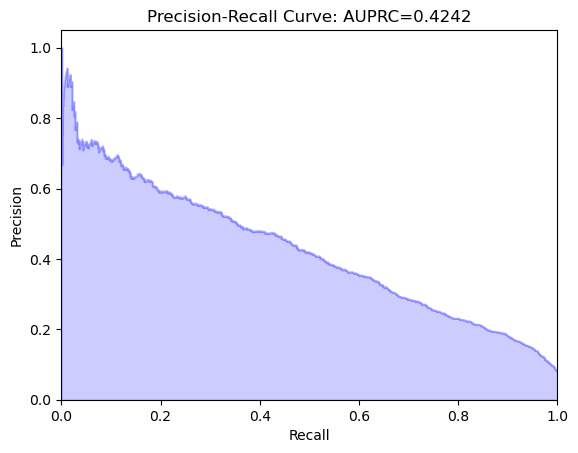

In [13]:
print("GradientBoosting:")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=random_seed)
start = time.time()
gb.fit(X_train, y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
test_probs = gb.predict_proba(X_test)
result = PlotROCCurve(test_probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)

results = ["GB"]
results.extend(result)
results.append(runtime)
result_list.append(results)

In [14]:
import pandas as pd
import numpy as np

test_probs = test_probs[:,1]

test_pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_test)),   # replace with real ID if available
    "y_true": y_test,
    "pred_prob_structured": test_probs
})

test_pred_df["y_true"] = test_pred_df["y_true"].astype(int)
test_pred_df.to_csv("structured_test_predictions_task2.csv", index=False)

test_pred_df.head()

,sample_id,y_true,pred_prob_structured
0,0,0,0.017748
1,1,0,0.017309
2,2,0,0.009830
3,3,0,0.014482
4,4,0,0.075333


GradientBoosting:
Training time: 25.269195795059204 seconds
AUC: 0.8591567089276282
AUPRC: 0.41582547320734187
Sensitivity: 0.7797147385103012
Specificity: 0.7736000000000001
Score thresold: 0.07356464748982262
2.5 97.5


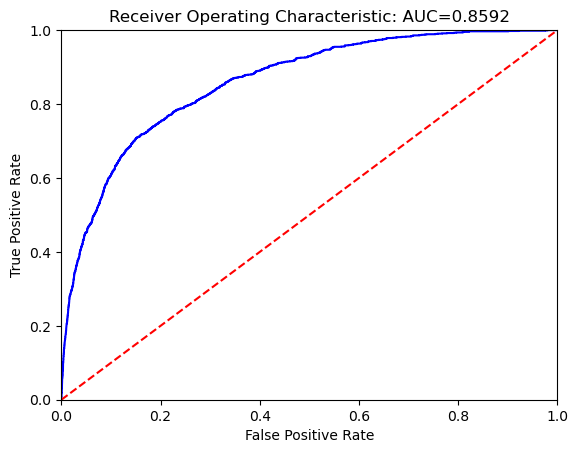

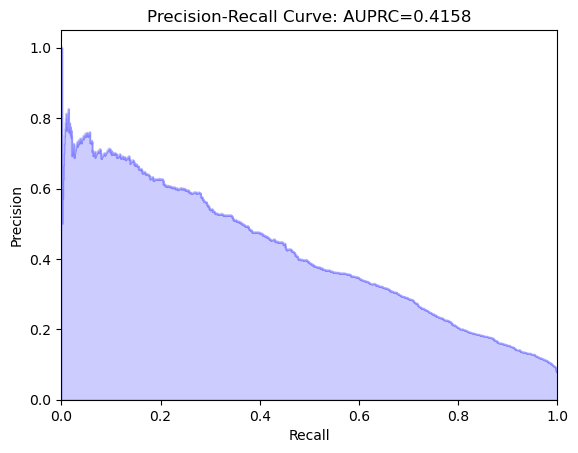

In [15]:
print("GradientBoosting:")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=random_seed)
start = time.time()
gb.fit(X_train, y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
val_probs = gb.predict_proba(X_val)
result = PlotROCCurve(val_probs[:,1],y_val, ci=confidence_interval, random_seed=random_seed)

results = ["GB"]
results.extend(result)
results.append(runtime)
result_list.append(results)

In [16]:
import pandas as pd
import numpy as np

val_probs = val_probs[:,1]

val_pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_val)),   # replace with real ID if available
    "y_true": y_val,
    "pred_prob_structured": val_probs
})

val_pred_df["y_true"] = val_pred_df["y_true"].astype(int)
val_pred_df.to_csv("structured_val_predictions_task2.csv", index=False)

val_pred_df.head()

,sample_id,y_true,pred_prob_structured
0,0,1,0.601427
1,1,0,0.036917
2,2,0,0.041250
3,3,0,0.205017
4,4,0,0.011207


In [17]:
class MLP(tf.keras.Model):
    def __init__(self):
        super(MLP, self).__init__()
        self.dense_1 = Dense(128, activation='relu')
        self.dense_2 = Dense(64, activation='relu')
        self.classifier = Dense(1, activation='sigmoid')

    def call(self, x):
        x = self.dense_1(x)
        x = self.dense_2(x)
        return self.classifier(x)

Epoch 1/20


2026-03-15 22:58:03.582120: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: agc04
2026-03-15 22:58:03.582143: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: agc04
2026-03-15 22:58:03.582322: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program
2026-03-15 22:58:03.582356: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 580.126.20


651/651 [==============================] - 2s 1ms/step - loss: 0.2914 - accuracy: 0.9166 - auc: 0.7265 - auprc: 0.2165 - tp: 730.0000 - tn: 118515.0000 - precision: 0.3980 - recall: 0.0697
Epoch 2/20
651/651 [==============================] - 1s 1ms/step - loss: 0.2376 - accuracy: 0.9199 - auc: 0.7863 - auprc: 0.2937 - tp: 1170.0000 - tn: 118505.0000 - precision: 0.5123 - recall: 0.1117
Epoch 3/20
651/651 [==============================] - 1s 1ms/step - loss: 0.2309 - accuracy: 0.9204 - auc: 0.8042 - auprc: 0.3182 - tp: 1320.0000 - tn: 118416.0000 - precision: 0.5232 - recall: 0.1260
Epoch 4/20
651/651 [==============================] - 1s 1ms/step - loss: 0.2310 - accuracy: 0.9203 - auc: 0.8053 - auprc: 0.3185 - tp: 1404.0000 - tn: 118320.0000 - precision: 0.5194 - recall: 0.1340
Epoch 5/20
651/651 [==============================] - 1s 1ms/step - loss: 0.2260 - accuracy: 0.9212 - auc: 0.8161 - auprc: 0.3371 - tp: 1461.0000 - tn: 118385.0000 - precision: 0.5421 - recall: 0.1395
Epoch 6

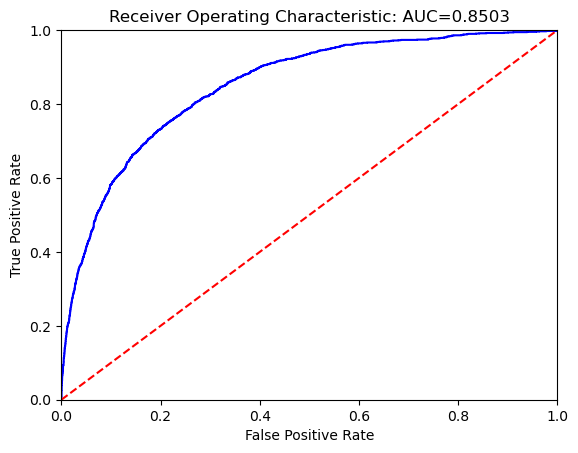

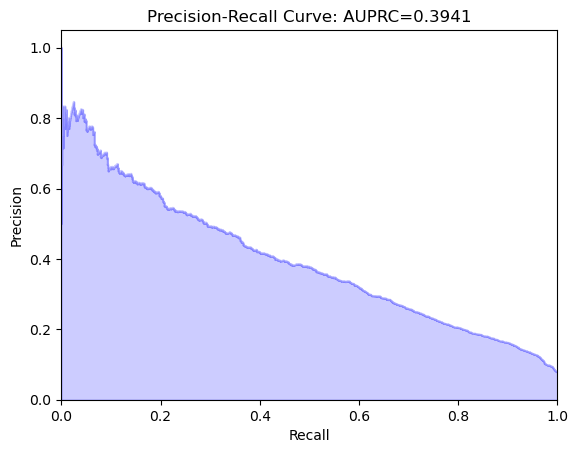

In [18]:
mlp = MLP()
mlp.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.001),
    metrics=[
        'accuracy',
        metrics.AUC(name='auc'),
        metrics.AUC(name='auprc', curve='PR'),
        metrics.TruePositives(name='tp'),
        metrics.TrueNegatives(name='tn'),
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall'),
    ]
)

start = time.time()
mlp.fit(X_train.astype(np.float32), y_train, batch_size=200, epochs=20)
runtime = time.time() - start
print('Training time:', runtime, 'seconds')

mlp.save('critical_triage_mlp_MV.keras')

print("MLP:")
probs = mlp.predict(X_test.astype(np.float32))
result = PlotROCCurve(probs, y_test, ci=confidence_interval, random_seed=random_seed)

results = ["MLP"]
results.extend(result)
results.append(runtime)
result_list.append(results)